# Neural Networks for Digit Images: MLP on 8×8 and CNN on Chinese MNIST

In this notebook I explore two small neural-network models for handwritten digits:

- **Multilayer Perceptron (MLP)** on the classic scikit-learn 8×8 digits dataset  
  - Input: flattened 8×8 grayscale images (64 features)  
  - Model: fully connected Keras network with Dense + Dropout layers  
  - Goal: see how a simple neural net compares to earlier linear models on this tiny dataset.

- **Convolutional Neural Network (CNN)** on the Chinese MNIST dataset  
  - Input: 64×64 grayscale images, 15 numeric labels (0–14) representing Chinese digits  
  - Model: small Conv2D + MaxPooling blocks followed by a Dense “head”  
  - Goal: handle a higher-resolution, more complex digit dataset and compare performance to simpler methods used in other notebooks.

This notebook focuses on:

- How MLPs and CNNs differ conceptually (flat vector vs 2D structure),
- How a CNN benefits from convolution and pooling on 64×64 images,
- Training and evaluation of both models using Keras.


1. Data loading and preprocessing (digits 8×8)

2026-05-15 20:02:18.137933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778875338.360810      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778875338.428381      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778875338.964496      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875338.964560      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875338.964563      16 computation_placer.cc:177] computation placer alr

X shape: (1797, 64)
y shape: (1797,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Train: (1149, 64) Val: (288, 64) Test: (360, 64)


Text(0.5, 0.98, 'Sample training digits')

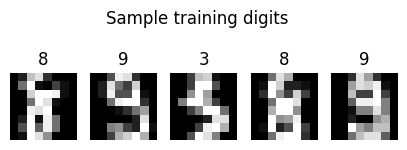

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# 1) Load the digits dataset
digits = load_digits()
X = digits.data          # shape: (1797, 64)  -> flattened 8x8
y = digits.target        # shape: (1797,)    -> labels 0–9

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

# 2) Train/validation/test split
# First split off test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Then split train_full into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=0, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# 3) Scale features (important for neural nets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# 4) Quick visual check of a few digits
plt.figure(figsize=(5, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].reshape(8, 8), cmap="gray")
    plt.axis("off")
    plt.title(str(y_train[i]))
plt.suptitle("Sample training digits")


2. Small MLP model + training + evaluation

In [2]:
num_features = X_train_scaled.shape[1]   # 64
num_classes = len(np.unique(y))

# 1) Build a simple MLP
model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

# 2) Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3) Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# 4) Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy (MLP on 8x8 digits):", test_acc)


2026-05-15 20:02:42.689946: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1986 - loss: 2.3327 - val_accuracy: 0.6042 - val_loss: 1.7342
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6302 - loss: 1.5267 - val_accuracy: 0.8507 - val_loss: 1.0248
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8133 - loss: 0.9098 - val_accuracy: 0.8993 - val_loss: 0.5797
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8670 - loss: 0.5663 - val_accuracy: 0.9028 - val_loss: 0.4062
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8961 - loss: 0.3863 - val_accuracy: 0.9271 - val_loss: 0.3015
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9273 - loss: 0.2770 - val_accuracy: 0.9410 - val_loss: 0.2511
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9419 - loss: 0.2240 - val_accuracy: 0.9479 - val_loss: 0.2250
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9621 - loss: 0.1777 - val_accuracy: 0.9514 - val_loss:

**CNN on Chinese MNIST**


Shape: (15000, 4098)
Index(['pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9'],
      dtype='object')
Unique raw labels: [        0         1         2         3         4         5         6
         7         8         9        10       100      1000     10000
 100000000]
Encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Number of classes: 15
Inferred image side: 64
X_imgs shape: (15000, 64, 64, 1)
y shape: (15000,)
Train: (9600, 64, 64, 1) Val: (2400, 64, 64, 1) Test: (3000, 64, 64, 1)


/tmp/ipykernel_16/1670162945.py:64: UserWarning: Glyph 20061 (\N{CJK UNIFIED IDEOGRAPH-4E5D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20061 (\N{CJK UNIFIED IDEOGRAPH-4E5D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


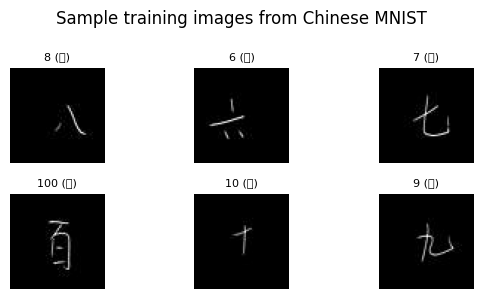

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

# 1) Load CSV
csv_path = "/kaggle/input/datasets/fedesoriano/chinese-mnist-digit-recognizer/chineseMNIST.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.columns[:10])

# 2) Separate pixels and raw labels
pixel_cols = [c for c in df.columns if c.startswith("pixel_")]
X = df[pixel_cols].values           # (15000, 4096)

y_raw = df["label"].values          # original numeric labels (0,1,2,...,10,100,...)
chars = df["character"].values

print("Unique raw labels:", np.unique(y_raw))

# 3) Encode labels to 0 .. num_classes-1
le = LabelEncoder()
y = le.fit_transform(y_raw)         # now y is 0..14
num_classes = len(le.classes_)

print("Encoded labels:", np.unique(y))
print("Number of classes:", num_classes)

# 4) Reshape to images and scale to [0, 1]
num_samples = X.shape[0]
side = int(np.sqrt(len(pixel_cols)))  # should be 64
print("Inferred image side:", side)

X_imgs = X.reshape(num_samples, side, side, 1).astype("float32") / 255.0

print("X_imgs shape:", X_imgs.shape)
print("y shape:", y.shape)

# 5) Train/validation/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_imgs, y, test_size=0.2, random_state=0, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=0, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# 6) Visual check of a few images (show both raw label and encoded index)
plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.axis("off")
    # decode back to raw value for display
    raw_label = le.inverse_transform([y_train[i]])[0]
    plt.title(f"{raw_label} ({chars[i]})", fontsize=8)
plt.suptitle("Sample training images from Chinese MNIST")
plt.tight_layout()
plt.show()


In [4]:
num_classes = len(np.unique(y))
input_shape = X_train.shape[1:]   # (64, 64, 1)

model_cnn = keras.Sequential([
    layers.Input(shape=input_shape),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 3 (a bit deeper, still small)
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model_cnn.summary()

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping to avoid overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print("Test accuracy (CNN on Chinese MNIST):", test_acc)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,311 (4.36 MB)

 Trainable params: 1,143,311 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.3900 - loss: 1.8599 - val_accuracy: 0.8637 - val_loss: 0.4193
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 273ms/step - accuracy: 0.8683 - loss: 0.4017 - val_accuracy: 0.9317 - val_loss: 0.2150
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 255ms/step - accuracy: 0.9216 - loss: 0.2389 - val_accuracy: 0.9550 - val_loss: 0.1502
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 253ms/step - accuracy: 0.9513 - loss: 0.1467 - val_accuracy: 0.9458 - val_loss: 0.1648
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 253ms/step - accuracy: 0.9554 - loss: 0.1318 - val_accuracy: 0.9563 - val_loss: 0.1359
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 255ms/step - accuracy: 0.9687 - loss: 0.0900 - val_accuracy: 0.9717 - val_loss: 0.1039
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 256ms/step - accuracy: 0.9767 - loss: 0.0713 - val_accuracy: 0.9775 - val_loss: 0.0825
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 265ms/step - accuracy: 0.9791 - loss: 0